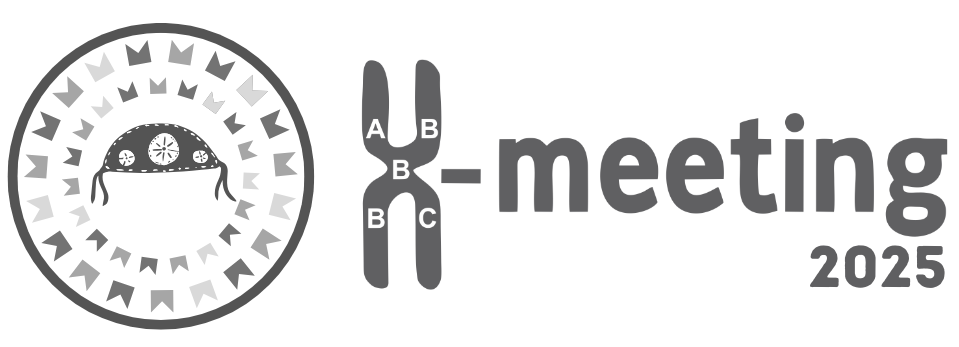

# **DAY 1**



*   What is Biopython and its main applications
*   Installing Biopython
*   The `Seq` object and basic manipulation methonds
*   Transcription, reverse transcription, and reverse complement
*   The `SeqRecord` object and sequence annotation
*   Handling .fasta and .gb files





Biopython_logo.svg

## Installing Biopython

There are several download options available, which can be checked on the official Biopython website.

The most recommended one is:

In [ ]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 26.8 MB/s eta 0:00:00


In [ ]:
#Checking the installation
import Bio

## Basic functions

The `Seq` objects are similar to standard Python strings.

In [ ]:
from Bio.Seq import Seq

#Seq Object
sequence = Seq("ATCGATCG")
print(type(sequence))

<class 'Bio.Seq.Seq'>


In [ ]:
#Accessing elements
print(sequence[0])
print(sequence[3])

A
G


### Concatenating
Useful when dealing with different contigs.

In [ ]:
#Concatenating
sequence1 = Seq("ATCGATCG")
sequence2 = Seq("AAAAAAAA")

complete_sequence = sequence1 + sequence2
print(complete_sequence)
print(type(complete_sequence))

ATCGATCGAAAAAAAA
<class 'Bio.Seq.Seq'>


In [ ]:
#Concatenating
seqs = [Seq("CCCC"), Seq("TTTT"), Seq("GGGG"), Seq("AAAA")]
concatenated = Seq("")

for s in seqs:
  concatenated += s

print(concatenated)

CCCCTTTTGGGGAAAA


In [ ]:
#Concatenating
seqs = [Seq("CCCC"), Seq("TTTT"), Seq("GGGG"), Seq("AAAA")]

sep = Seq("N"*6)

conc_seqs = sep.join(seqs)
print(conc_seqs)

CCCCNNNNNNTTTTNNNNNNGGGGNNNNNNAAAA


### Count
The `count()` method is useful when we need to determine the frequency of nucleotides, amino acids, or specific motifs within a sequence. Similar to a Python string, this gives a non-overlapping count.

In [ ]:
#Counting
print(complete_sequence)

a_count = complete_sequence.count("A")
print(a_count)

ga_count = complete_sequence.count("GA")
print(ga_count)

ATCGATCGAAAAAAAA
10
2


### Len
When using the `len()` function on a `Seq` object, we obtain the number of characters in the sequence. It is useful for determining the length of genomes and proteins.

In [ ]:
#Sequence length
length = len(complete_sequence)
print(length)

print(len(complete_sequence))

16
16


### GC fraction
The `Bio.SeqUtils` module provides a dedicated function to calculate the GC fraction, which automatically handles mixed-case sequences and accounts for the ambiguous nucleotide S, representing either G or C.

In [ ]:
#GC fraction
from Bio.SeqUtils import gc_fraction

gc_content = gc_fraction(complete_sequence)
print(gc_content)

0.25


In [ ]:
gc_fraction = (complete_sequence.count("G") + complete_sequence.count("C")) / len(complete_sequence)
print(gc_fraction)

0.25


### Loops e conditionals
We can iterate over the elements of a sequence just like we do with strings in Python, enabling the use of loops and conditionals to analyze or manipulate each nucleotide or amino acid individually.

In [ ]:
#Loops and conditionals
print(complete_sequence)
for base in complete_sequence:
  if base == "G":
    print("Guanine")
  else:
    print("Other base")

ATCGATCGAAAAAAAA
Other base
Other base
Other base
Guanine
Other base
Other base
Other base
Guanine
Other base
Other base
Other base
Other base
Other base
Other base
Other base
Other base


In [ ]:
positions = []
print(complete_sequence)

for i, nucleotide in enumerate(complete_sequence):
  if nucleotide == "T":
    positions.append(i)

print("Thymine found at positions:", positions)

ATCGATCGAAAAAAAA
Thymine found at positions: [1, 5]


### Comparing sequences
In Biopython, `Seq` objects can be compared directly using standard operators.

In [ ]:
#Comparison
print(sequence1)
print(sequence2)

if sequence1 == sequence2:
  print("Sequences are equal")
else:
  print("Sequences are different")

ATCGATCG
AAAAAAAA
Sequences are different


In [ ]:
#Comparison
if sequence1 in complete_sequence:
  print("Complete sequence contains sequence1")

Complete sequence contains sequence1


### Slicing a sequence
We can extract subsequences by specifying start and end positions. Similar to Python strings, slicing includes the first position but excludes the last one.

In [ ]:
#Slicing
print(sequence1)

print(sequence1[1:4])

print(sequence1[-2])

ATCGATCG
TCG
C


In [ ]:
#Slicing - ride
myseq = Seq("ATGCGAATTGCGCATATA")
print(myseq)
print(myseq[0::3])


ATGCGAATTGCGCATATA
ACAGCA


### Upper and lower
The `upper()` and `lower()` methods allow to convert a sequence to uppercase or lowercase, respectively. These functions are useful when standardizing nucleotide or protein sequences for comparison, alignment, or data formatting.

In [ ]:
#Changing case
dna_seq = Seq("acgtACTG")


print(dna_seq.upper())

print(dna_seq.lower())

ACGTACTG
acgtactg


In [ ]:
print(dna_seq.count("c"))
print(dna_seq.count("C"))

1
1


In [ ]:
"GTAC" in dna_seq

False

In [ ]:
"GTAC" in dna_seq.upper()

True

## Practicing
You have received a raw genome sequence of a new organism. Your goal is to perform an initial analysis to identify possible coding genes and obtain basic sequence statistics.

**Sequence:**
atgCTagcTAgcATgttggcATGgtagcTatgctggCATgatgctAGCatgctGGCATGCgaTgCGATtgcgATGtaGcttgcgatATGgctagcTAGctagctGCgtaTGCatgctAGGatgcatGCTatGCgtacTGAatgcTAGgcaTGCgatgCATgcATGcga


**Instructions:**

**1. Sequence Standardization:**
Convert the received sequence to uppercase letters, ensuring consistency in the analysis.

**2. Quality Check:**
Print the sequence length to verify its completeness.

**3. Base Analysis:**
Count the occurrence of each nucleotide (A, T, C, G) in the sequence.
Calculate the GC fraction and display the result as a percentage.

**4. Identification of start codons:**
Extract the codons from the sequence and identify the positions of start codons (ATG).

**Final Report:**
Organize the obtained information into a simple, printed report.

In [ ]:
print("1. Sequence Standardization:", dna_seq)

In [ ]:
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction


#1. Sequence Standardization
dna = Seq("atgCTagcTAgcATgttggcATGgtagcTatgctggCATgatgctAGCatgctGGCATGCgaTgCGATtgcgATGtaGcttgcgatATGgctagcTAGctagctGCgtaTGCatgctAGGatgcatGCTatGCgtacTGAatgcTAGgcaTGCgatgCATgcATGcga")
dna = dna.upper()
print("DNA sequence:", dna)

#2. Quality Check
length2 = len(dna)
print(f"O tamanho da sequência é {length2} nucleotídeos")

#3. Base Analysis
base_counts = {base: dna.count(base) for base in "ATCG"}
print("Contagem de bases na sequência", base_counts)

gc_dna = gc_fraction(dna) * 100
print("A porcentagem de GC na sequência é:", gc_dna)

#4. Identification of start codons:
start_positions = [i for i in range(0, len(dna) - 2, 3) if dna[i:i+3] == "ATG"]
print("Start codon positions:", start_positions)





DNA sequence: ATGCTAGCTAGCATGTTGGCATGGTAGCTATGCTGGCATGATGCTAGCATGCTGGCATGCGATGCGATTGCGATGTAGCTTGCGATATGGCTAGCTAGCTAGCTGCGTATGCATGCTAGGATGCATGCTATGCGTACTGAATGCTAGGCATGCGATGCATGCATGCGA
O tamanho da sequência é 168 nucleotídeos
Contagem de bases na sequência {'A': 36, 'T': 46, 'C': 33, 'G': 53}
A porcentagem de GC na sequência é: 51.19047619047619
Start codon positions: [0, 12, 48, 72, 108, 120, 129, 162]


### MutableSeq
The `Seq` object is "read only", or immutable.

In [ ]:
myseq = Seq("ATTCG")
myseq[0] = "C"
print(myseq)

To deal with this, we can convert it into a mutable sequence (a `MutableSeq` object):

In [ ]:
from Bio.Seq import MutableSeq

mutable_seq = MutableSeq(myseq)
print(type(mutable_seq))

print(mutable_seq)

mutable_seq[0] = "C"

print(mutable_seq)

<class 'Bio.Seq.MutableSeq'>
ATTCG
CTTCG


In [ ]:
mutable_seq.remove("T")

print(mutable_seq)

CTCG


In [ ]:
mutable_seq2 = MutableSeq("AAAGGGTCGTGCATACAGG")
mutable_seq2.reverse()
print(mutable_seq2)

GGACATACGTGCTGGGAAA


In [ ]:
#Get back to a read-only Seq object
from Bio.Seq import Seq
new_seq = Seq(mutable_seq2)
print(type(new_seq))

<class 'Bio.Seq.Seq'>


### Transcription
In bioinformatics, sequences are always in the 5'-3' sense.


5' - ATCG - 3'  Coding strand/Sense


3' - TAGC - 5'  Template strand/Antisense

In [ ]:
from Bio.Seq import Seq

sense = Seq("ATCG")
antisense = Seq("CGAT")

#Direct transcription from the coding strand
transcript = sense.transcribe()
print(transcript)


AUCG


In [ ]:
#Transcription from the template strand
temp_transcript = antisense.reverse_complement().transcribe()
print(temp_transcript)

AUCG


In [ ]:
#Reverse transcription
rna_seq = Seq("AUCGGAUUAGCA")

dna_seq = rna_seq.back_transcribe()
print(dna_seq)

ATCGGATTAGCA


### Translation

In [ ]:
#Translation
rna_seq = Seq("AUCGGAUUAGCAAUCGGAUUAGCAAUCGGAUUAGCAUAAGCCCCGGAA")
dna_seq = Seq("ATCGGATTAGCAATCGGATTAGCAATCGGATTAGCATAAGCCCCGGAA")

#From RNA
protein1 = rna_seq.translate()
print(protein1)

#From DNA
protein2 = dna_seq.translate()
print(protein2)


if protein1 == protein2:
  print("Proteins are equal")
else:
  print("Proteins are different")

IGLAIGLAIGLA*APE
IGLAIGLAIGLA*APE
Proteins are equal


In [ ]:
#Until stopcodon
protein3 = rna_seq.translate(to_stop=True)
print(protein3)

IGLAIGLAIGLA


The translation tables available in Biopython are based on those from the NCBI.

By default, translation will use the standard genetic code (NCBI table id 1).

You can specify the table using the [NCBI table number](https://www.ncbi.nlm.nih.gov/Taxonomy/Utils/wprintgc.cgi) (often included in the feature annotation of GenBank files):

In [ ]:
protein4 = rna_seq.translate(table=6)
print(protein4)

if protein1 == protein4:
  print("Proteins are equal")
else:
  print("Proteins are different")

IGLAIGLAIGLAQAPE
Proteins are different


## Practicing
**From the DNA sequence, you will:**

Obtain the RNA through transcription;

Obtain the reverse complementary strand;

Translate the RNA into a protein (amino acids).

**DNA sequence:**
ATGGCGGCGCTGACGGTATCGGTTACATGGCGGCGCTGACGGTATCGGTTACGTTGAGGCGTTCGATGTGGTGAAGGCCGACGATGTGCTGAAGATGCGTTAGGTTGAGGCGTTCGATATGGCGGCGCTGACGGTATCGGTTACGTTGAGGCGTTCGATGTGGTGAAGGCCGACGATGTGCTGAAGATGCGTTAGGTGGTGAATGGCGGCGCTGACGGTATCGGTTACGTTGAGGCGTTCGATGTGGTGAAGGCCGACGATGTGCTGAAGATGCGTTAGAGGCCGACGATGTGCTGAAGATGCGTTAG

In [ ]:
#Solution
dna = Seq("ATGGCGGCGCTGACGGTATCGGTTACATGGCGGCGCTGACGGTATCGGTTACGTTGAGGCGTTCGATGTGGTGAAGGCCGACGATGTGCTGAAGATGCGTTAGGTTGAGGCGTTCGATATGGCGGCGCTGACGGTATCGGTTACGTTGAGGCGTTCGATGTGGTGAAGGCCGACGATGTGCTGAAGATGCGTTAGGTGGTGAATGGCGGCGCTGACGGTATCGGTTACGTTGAGGCGTTCGATGTGGTGAAGGCCGACGATGTGCTGAAGATGCGTTAGAGGCCGACGATGTGCTGAAGATGCGTTAG")
#Transcription
rna_seq = dna.transcribe()
print("RNA:", rna_seq)

#Reverse complement
rev_comp = dna.reverse_complement()
print("Reverse complement:", rev_comp)

#Translation
protein = dna.translate()
print("Protein:", protein)

RNA: AUGGCGGCGCUGACGGUAUCGGUUACAUGGCGGCGCUGACGGUAUCGGUUACGUUGAGGCGUUCGAUGUGGUGAAGGCCGACGAUGUGCUGAAGAUGCGUUAGGUUGAGGCGUUCGAUAUGGCGGCGCUGACGGUAUCGGUUACGUUGAGGCGUUCGAUGUGGUGAAGGCCGACGAUGUGCUGAAGAUGCGUUAGGUGGUGAAUGGCGGCGCUGACGGUAUCGGUUACGUUGAGGCGUUCGAUGUGGUGAAGGCCGACGAUGUGCUGAAGAUGCGUUAGAGGCCGACGAUGUGCUGAAGAUGCGUUAG
Reverse complement: CTAACGCATCTTCAGCACATCGTCGGCCTCTAACGCATCTTCAGCACATCGTCGGCCTTCACCACATCGAACGCCTCAACGTAACCGATACCGTCAGCGCCGCCATTCACCACCTAACGCATCTTCAGCACATCGTCGGCCTTCACCACATCGAACGCCTCAACGTAACCGATACCGTCAGCGCCGCCATATCGAACGCCTCAACCTAACGCATCTTCAGCACATCGTCGGCCTTCACCACATCGAACGCCTCAACGTAACCGATACCGTCAGCGCCGCCATGTAACCGATACCGTCAGCGCCGCCAT
Protein: MAALTVSVTWRR*RYRLR*GVRCGEGRRCAEDALG*GVRYGGADGIGYVEAFDVVKADDVLKMR*VVNGGADGIGYVEAFDVVKADDVLKMR*RPTMC*RCV


/usr/local/lib/python3.11/dist-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


## Sequence annotation objects

The Sequence Record (`SeqRecord`) class allows higher level features to be associated with the sequence.

#### Main attributes:


*   `.seq`: The sequence itself, a `Seq` object
*   `.id`: The primary ID used to identify the sequence, a string
*   `.name`: A "common" name/id for the sequence, a string
*   `.description`: A human readable description for the sequence, a string
*   `.annotations`: A dictionary of additional information about the sequence. This allows the addition of more "unstructured" information to the sequence
*   `.features`: A list of `SeqFeature` objects with more structured information about the features on a sequence (e.g. position of genes on a genome, or domains on a protein sequence)

### Creating a SeqRecord
Usually you won't create a `SeqRecord` "by hand", but instead use `Bio.SeqIO` to read in a sequence file.

However, creating a `SeqRecord` can be quite simple:

In [ ]:
from Bio.Seq import Seq
seq1 = Seq("ATCGTCGAT")

from Bio.SeqRecord import SeqRecord
seq1_r = SeqRecord(seq1)

In [ ]:
print(seq1_r)

ID: <unknown id>
Name: <unknown name>
Description: <unknown description>
Number of features: 0
Seq('ATCGTCGAT')


In [ ]:
print(type(seq1_r))

<class 'Bio.SeqRecord.SeqRecord'>


In [ ]:
seq1_r.id

'<unknown id>'

In [ ]:
seq1_r.id = "SEQUENCE1"
seq1_r.description = "Sequence description example"

In [ ]:
print(seq1_r)

ID: SEQUENCE1
Name: <unknown name>
Description: Sequence description example
Number of features: 0
Seq('ATCGTCGAT')


In [ ]:
print(seq1_r.description)

Sequence description example


In [ ]:
#Including an identifier when creating the object
from Bio.Seq import Seq
seq2 = Seq("GTCATGCCTAGC")

from Bio.SeqRecord import SeqRecord
seq2_r = SeqRecord(seq2, id="SEQUENCE2", description="Example 2", name="sequencia2")

print(seq2_r)

ID: SEQUENCE2
Name: sequencia2
Description: Example 2
Number of features: 0
Seq('GTCATGCCTAGC')


In [ ]:
seq2_r.annotations["genome"] = "Genome 2 example"
print(seq2_r)

ID: SEQUENCE2
Name: sequencia2
Description: Example 2
Number of features: 0
/genome=Genome 2 example
Seq('GTCATGCCTAGC')


In [ ]:
print(seq2_r.annotations)

{'genome': 'Genome 2 example'}


In [ ]:
print(seq2_r.annotations["genome"])

Genome 2 example


In [ ]:
#Setting the working directory
import os
os.chdir("/content/drive/MyDrive/xmeeting_biopython")

#Writing a fasta file
from Bio import SeqIO
SeqIO.write(seq2_r, "output_seq2.fna", "fasta")

1